train shape: (1460, 81)
test shape: (1459, 80)
GrLivArea外れ値: 2件
y_train shape: (1458,)
総特徴量: 46個
欠損値処理中...
X_train shape: (1458, 46)
X_test shape: (1459, 46)

特徴量重要度分析中...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[113]	valid_0's rmse: 0.127566
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[191]	valid_0's rmse: 0.130211
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[132]	valid_0's rmse: 0.140147
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[164]	valid_0's rmse: 0.138041
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[148]	valid_0's rmse: 0.121581

【Top 20 重要な特徴量】
     feature  importance       std
     LotArea       326.6 81.818702
 QualTotalSF       289.4 55.229521
 AreaPerRoom       216.0 76.599608
     TotalSF       199.2 35.821

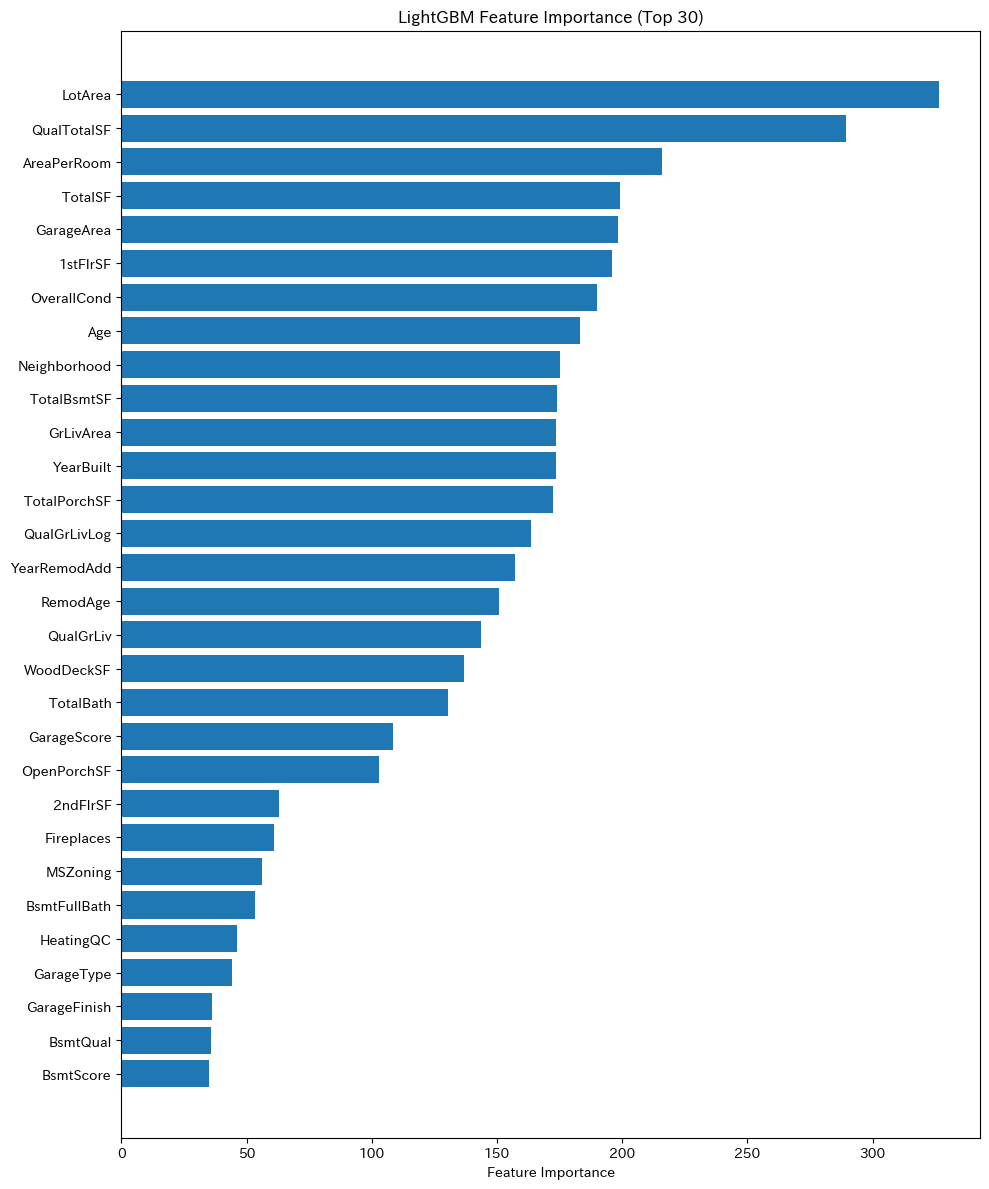

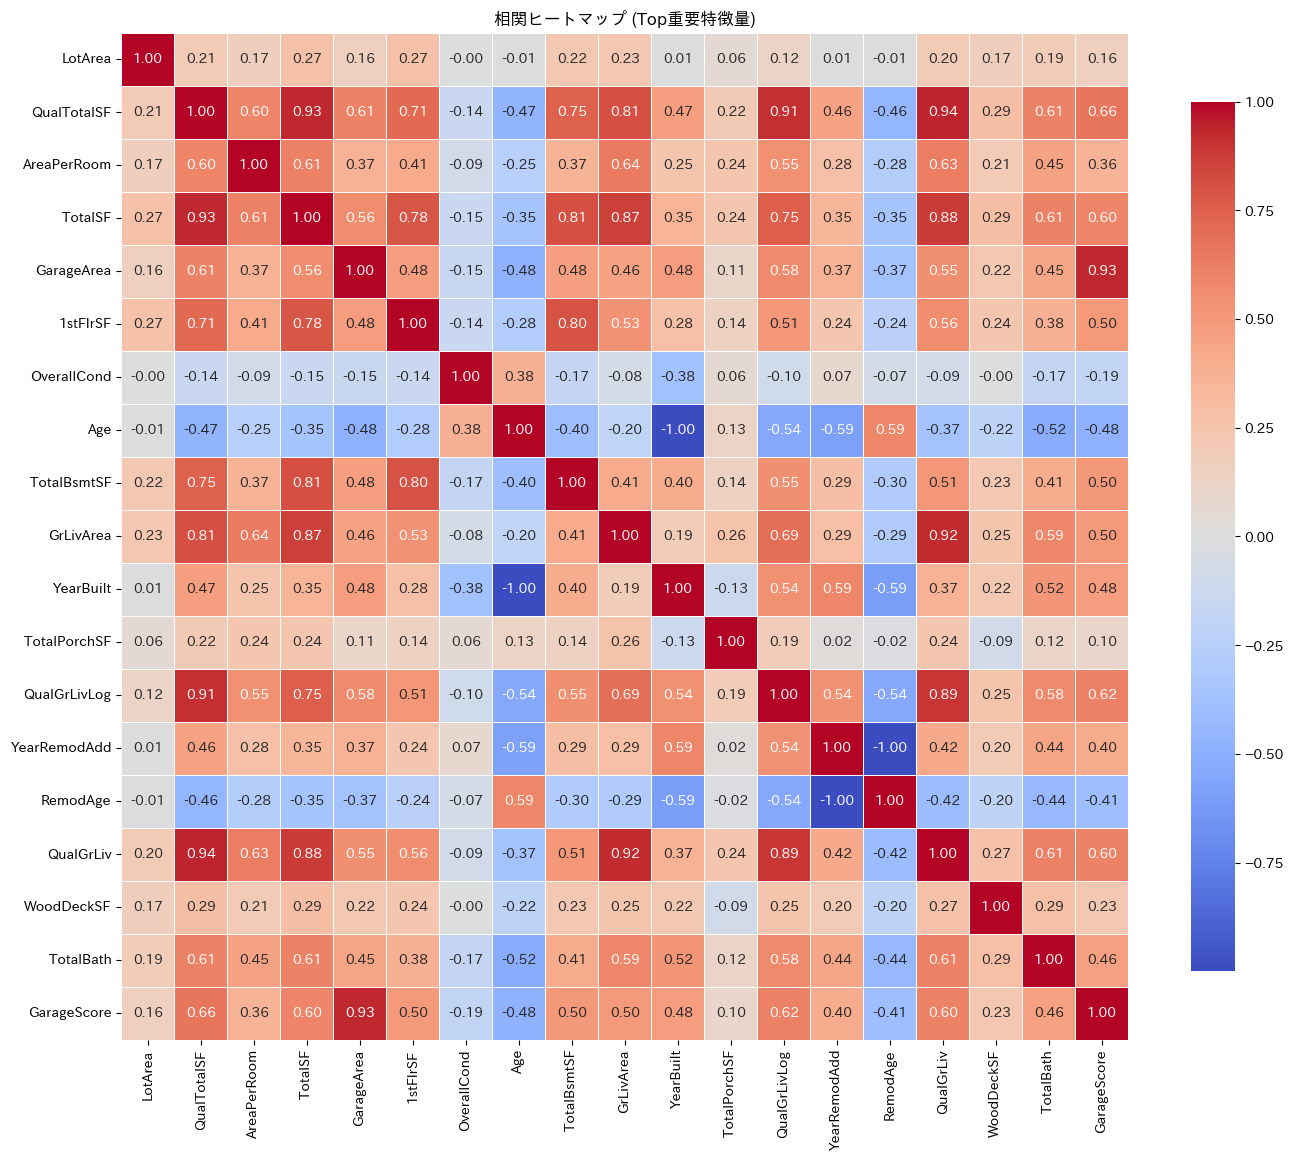

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib
from sklearn.preprocessing import LabelEncoder, StandardScaler
import lightgbm as lgb
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")

class Paths:
    p = "/Users/shirokoshikentaro/Desktop/Python3/house-prices-advanced-regression-techniques"
    train = p + "/train.csv"
    test = p + "/test.csv"
    sample = p + "/sample_submission.csv"

# ===== ステップ1: データ読み込み =====
train = pd.read_csv(Paths.train)
test = pd.read_csv(Paths.test)

print(f"train shape: {train.shape}")
print(f"test shape: {test.shape}")

# 外れ値除去
outliers = train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)].index
print(f"GrLivArea外れ値: {len(outliers)}件")
train = train.drop(outliers)

y_train = np.log1p(train["SalePrice"].values)
print(f"y_train shape: {y_train.shape}")

# ===== ステップ2: 新規特徴量作成 =====
for df in [train, test]:
    df["QualGrLiv"] = df["OverallQual"] * df["GrLivArea"]
    df["TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]
    df["QualTotalSF"] = df["OverallQual"] * df["TotalSF"]
    df["Age"] = df["YrSold"] - df["YearBuilt"]
    df["RemodAge"] = df["YrSold"] - df["YearRemodAdd"]
    df["TotalBath"] = (df["FullBath"] + 0.5*df["HalfBath"].fillna(0) + 
                       df["BsmtFullBath"].fillna(0) + 0.5*df["BsmtHalfBath"].fillna(0))
    df["AreaPerRoom"] = df["GrLivArea"] / df["TotRmsAbvGrd"].replace(0, 1)
    df["GarageScore"] = df["GarageCars"] * df["GarageArea"]

    df["Log_GrLivArea"] = np.log1p(df["GrLivArea"])
    df["Log_LotArea"] = np.log1p(df["LotArea"])
    df["Log_TotalSF"] = np.log1p(df["TotalSF"])
    
    df["QualGrLivLog"] = df["OverallQual"] * df["Log_GrLivArea"]
    df["TotalPorchSF"] = (df["OpenPorchSF"] + df["EnclosedPorch"] + 
                          df["3SsnPorch"].fillna(0) + df["ScreenPorch"].fillna(0))
    df["IsNew"] = (df["Age"] <= 5).astype(int)
    df["IsRemodeled"] = (df["YearRemodAdd"] != df["YearBuilt"]).astype(int)
    df["HasBsmt"] = (df["TotalBsmtSF"] > 0).astype(int)
    df["BsmtScore"] = df["TotalBsmtSF"] * df["HasBsmt"]

# ===== ステップ3: 特徴量定義 =====
num_features = [
    "LotArea", "YearBuilt", "YearRemodAdd",
    "GrLivArea", "TotalBsmtSF", "1stFlrSF", "2ndFlrSF",
    "FullBath", "BedroomAbvGr", "TotRmsAbvGrd",
    "GarageCars", "GarageArea", "OverallQual", "OverallCond",
    "QualGrLiv", "TotalSF", "QualTotalSF", 
    "Age", "RemodAge", "TotalBath", "AreaPerRoom", "GarageScore",
    "WoodDeckSF", "OpenPorchSF", "EnclosedPorch",
    "Fireplaces", "HalfBath", "BsmtFullBath",
    "QualGrLivLog", "TotalPorchSF", "IsNew", "IsRemodeled", 
    "HasBsmt", "BsmtScore",
]

cat_features = [
    "Neighborhood", "BldgType", "HouseStyle",
    "MSZoning", "Foundation", "GarageType",
    "ExterQual", "KitchenQual", "BsmtQual",
    "HeatingQC", "FireplaceQu", "GarageFinish",
]

all_features = num_features + cat_features
print(f"総特徴量: {len(all_features)}個")

# ===== ステップ4: 欠損値処理 =====
print("欠損値処理中...")
for col in num_features:
    train[col] = train[col].fillna(0)
    test[col] = test[col].fillna(0)

for col in cat_features:
    train[col] = train[col].fillna("None")
    test[col] = test[col].fillna("None")

# ===== ステップ5: エンコーディング =====
for col in cat_features:
    le = LabelEncoder()
    combined = pd.concat([train[col].astype(str), test[col].astype(str)])
    le.fit(combined)
    train[col] = le.transform(train[col].astype(str))
    test[col] = le.transform(test[col].astype(str))

# ===== ステップ6: X_train, X_test作成 =====
X_train = train[all_features].values
X_test = test[all_features].values

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

# ===== ステップ7: 特徴量重要度分析 =====
print("\n" + "="*60)
print("特徴量重要度分析中...")
print("="*60)

params_lgb = {
    "boosting_type": "gbdt",
    "objective": "regression",
    "metric": "rmse",
    "num_leaves": 31,
    "learning_rate": 0.05,
    "n_estimators": 10000,
    "min_child_samples": 20,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 0.1,
    "random_state": 123,
    "verbose": -1,
}

# 特徴量重要度を蓄積
importance_df = pd.DataFrame()
importance_df['feature'] = all_features

cv = KFold(n_splits=5, shuffle=True, random_state=123)

for fold, (tr_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
    X_tr, y_tr = X_train[tr_idx], y_train[tr_idx]
    X_val, y_val = X_train[val_idx], y_train[val_idx]
    
    model_lgb = lgb.LGBMRegressor(**params_lgb)
    model_lgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
                  callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)])
    
    # 各foldの重要度を保存
    importance_df[f'fold_{fold}'] = model_lgb.feature_importances_

# 平均重要度を計算
fold_cols = [col for col in importance_df.columns if 'fold_' in col]
importance_df['importance'] = importance_df[fold_cols].mean(axis=1)
importance_df['std'] = importance_df[fold_cols].std(axis=1)

# 重要度順にソート
importance_df = importance_df.sort_values('importance', ascending=False).reset_index(drop=True)

# Top 20表示
print("\n【Top 20 重要な特徴量】")
print(importance_df[['feature', 'importance', 'std']].head(20).to_string(index=False))

# Bottom 10表示
print("\n【Bottom 10 重要度が低い特徴量】")
print(importance_df[['feature', 'importance', 'std']].tail(10).to_string(index=False))

# 可視化
plt.figure(figsize=(10, 12))
top_n = 30
data = importance_df.head(top_n).sort_values('importance')
plt.barh(range(len(data)), data['importance'])
plt.yticks(range(len(data)), data['feature'])
plt.xlabel('Feature Importance')
plt.title(f'LightGBM Feature Importance (Top {top_n})')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
print("\n✅ feature_importance.png を保存しました")

# 相関分析（数値特徴量のみ）
print("\n" + "="*60)
print("相関分析中...")
print("="*60)

# 目的変数との相関
train_with_target = train[num_features].copy()
train_with_target['SalePrice'] = np.expm1(y_train)

correlations = train_with_target.corr()['SalePrice'].sort_values(ascending=False)
print("\n【目的変数との相関 Top 15】")
print(correlations.head(15))

print("\n【目的変数との相関 Bottom 10】")
print(correlations.tail(10))

# 相関ヒートマップ（Top 20の特徴量のみ）
top_features = importance_df.head(20)['feature'].tolist()
top_num_features = [f for f in top_features if f in num_features]

if len(top_num_features) > 0:
    plt.figure(figsize=(14, 12))
    corr_matrix = train[top_num_features].corr()
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title('相関ヒートマップ (Top重要特徴量)')
    plt.tight_layout()
    plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
    print("\n✅ correlation_heatmap.png を保存しました")

# ===== ステップ8: 重要度の低い特徴量を除外して再学習 =====
print("\n" + "="*60)
print("重要度の低い特徴量を除外して再学習...")
print("="*60)

# 重要度が平均の10%未満の特徴量を除外
threshold = importance_df['importance'].mean() * 0.1
low_importance_features = importance_df[importance_df['importance'] < threshold]['feature'].tolist()

print(f"\n除外する特徴量 ({len(low_importance_features)}個):")
print(low_importance_features)

# 選択された特徴量
selected_features = [f for f in all_features if f not in low_importance_features]
print(f"\n選択された特徴量: {len(selected_features)}個")

X_train_selected = train[selected_features].values
X_test_selected = test[selected_features].values

# ===== ステップ9: アンサンブル学習（選択後） =====
lgb_oof = np.zeros(len(X_train_selected))
ridge_oof = np.zeros(len(X_train_selected))
lasso_oof = np.zeros(len(X_train_selected))

lgb_test_preds = []
ridge_test_preds = []
lasso_test_preds = []

print("\n=== CV with Ensemble (Selected Features) ===")
for fold, (tr_idx, val_idx) in enumerate(cv.split(X_train_selected, y_train)):
    X_tr, y_tr = X_train_selected[tr_idx], y_train[tr_idx]
    X_val, y_val = X_train_selected[val_idx], y_train[val_idx]
    
    # LightGBM
    model_lgb = lgb.LGBMRegressor(**params_lgb)
    model_lgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
                  callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)])
    lgb_oof[val_idx] = model_lgb.predict(X_val)
    lgb_test_preds.append(model_lgb.predict(X_test_selected))
    
    # Ridge回帰
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test_selected)
    
    model_ridge = Ridge(alpha=10, random_state=123)
    model_ridge.fit(X_tr_scaled, y_tr)
    ridge_oof[val_idx] = model_ridge.predict(X_val_scaled)
    ridge_test_preds.append(model_ridge.predict(X_test_scaled))
    
    # Lasso回帰
    model_lasso = Lasso(alpha=0.0005, random_state=123, max_iter=5000)
    model_lasso.fit(X_tr_scaled, y_tr)
    lasso_oof[val_idx] = model_lasso.predict(X_val_scaled)
    lasso_test_preds.append(model_lasso.predict(X_test_scaled))
    
    print(f"Fold {fold} completed")

# 個別スコア
lgb_score = np.sqrt(mean_squared_error(y_train, lgb_oof))
ridge_score = np.sqrt(mean_squared_error(y_train, ridge_oof))
lasso_score = np.sqrt(mean_squared_error(y_train, lasso_oof))

print(f"\n[Individual Scores - Selected Features]")
print(f"LightGBM: {lgb_score:.5f}")
print(f"Ridge:    {ridge_score:.5f}")
print(f"Lasso:    {lasso_score:.5f}")

# アンサンブルの重み探索
best_score = float('inf')
best_weights = None

for w_lgb in np.arange(0.5, 0.9, 0.05):
    for w_ridge in np.arange(0.05, 0.4, 0.05):
        w_lasso = 1.0 - w_lgb - w_ridge
        if w_lasso < 0 or w_lasso > 0.5:
            continue
        
        ensemble_oof = w_lgb * lgb_oof + w_ridge * ridge_oof + w_lasso * lasso_oof
        score = np.sqrt(mean_squared_error(y_train, ensemble_oof))
        
        if score < best_score:
            best_score = score
            best_weights = (w_lgb, w_ridge, w_lasso)

print(f"\n[Best Ensemble - Selected Features]")
print(f"Weights: LGB={best_weights[0]:.3f}, Ridge={best_weights[1]:.3f}, Lasso={best_weights[2]:.3f}")
print(f"CV Score: {best_score:.5f}")

# テストデータの予測
lgb_test_pred = np.mean(lgb_test_preds, axis=0)
ridge_test_pred = np.mean(ridge_test_preds, axis=0)
lasso_test_pred = np.mean(lasso_test_preds, axis=0)

y_pred_log = (best_weights[0] * lgb_test_pred + 
              best_weights[1] * ridge_test_pred + 
              best_weights[2] * lasso_test_pred)
y_pred = np.expm1(y_pred_log)

# ===== ステップ10: 提出ファイル =====
submission = pd.DataFrame({
    "Id": test["Id"],
    "SalePrice": y_pred
})

submission.to_csv("submission_feature_selected.csv", index=False)
print(f"\n✅ 保存完了！平均予測価格: ${y_pred.mean():,.0f}")

# 分析結果をCSVで保存
importance_df.to_csv("feature_importance.csv", index=False)
print("✅ feature_importance.csv を保存しました")

print("\n" + "="*60)
print("全処理完了！")
print("="*60)